In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import pandas as pd
import os
from typing import Dict
import pickle
from scipy.stats import linregress


def set_default_plot_style():
    plt.style.use("default")  # start clean

    plt.rcParams["axes.grid"] = True
    plt.rcParams["grid.alpha"] = 0.2
    plt.rcParams["grid.linestyle"] = "-"
    plt.rcParams["grid.color"] = "gray"

    plt.rcParams["axes.spines.top"] = False
    plt.rcParams["axes.spines.right"] = False

    plt.rcParams["axes.linewidth"] = 1.2

    plt.rcParams["legend.frameon"] = False

    plt.rcParams["font.size"] = 25
    plt.rcParams["axes.labelsize"] = 35
    plt.rcParams["legend.fontsize"] = 21

    mpl.rcParams['text.usetex'] = True
    mpl.rcParams['font.family'] = 'serif'
    mpl.rcParams['font.serif'] = ['Computer Modern Roman']

# Call once at the top of your script
set_default_plot_style()


In [4]:
# Helpful funcs
def log_b(x, b):
    return np.log(x) / np.log(b)


In [5]:
L_vals = [2500, 5000, 10000, 20000]

epdilon_vals = [0.212925]

time_prefact = 5000
num_initial_conds = 4000
initial_state_prob = 0.5

time_step = 150000

cmap2 = plt.colormaps.get_cmap("Blues").resampled(len(L_vals) + 5)


read_external_drive = True
write_external_drive = read_external_drive and True
local_data_parent_folder = "data"
if read_external_drive:
    data_parent_folder = "/Volumes/ExternalData/stavskya_mc/data"
    if write_external_drive:
        local_data_parent_folder = "/Volumes/ExternalData/stavskya_mc/data"
else:
    data_parent_folder = local_data_parent_folder


In [6]:
# If first time

collected_rhos = {}
collected_rho_stds = {}

for L_val in L_vals:
    print(f"L_val: {L_val}")

    T_f = round(L_val*time_prefact)
    collected_rhos[L_val] = {}
    collected_rho_stds[L_val] = {}

    for epdilon in epdilon_vals:
        print(f"L_val: {L_val} | epsilon: {epdilon}")
        epsilon_val_name = f"{epdilon}".replace(".", "p")

        current_rhos = [[0.0 for _ in range(round(L_val * time_prefact / time_step))] for _ in range(num_initial_conds)]
        for init_cond in range(num_initial_conds, 0, -1):
            sample_filepath_name = os.path.join(data_parent_folder, f"time_rand_binary/rho_per_time/IC1/L{L_val}//epsilon{epsilon_val_name}/IC1_L{L_val}_epsilon{epsilon_val_name}_timepref{time_prefact}_timestep{time_step}_sample{init_cond}.csv")
            try:
                df = pd.read_csv(sample_filepath_name)

                current_rhos[init_cond-1] = df.rho
            except Exception as e:
                current_rhos.pop(init_cond-1)
                print(e)
                print(sample_filepath_name)
        
        current_rhos = np.array(current_rhos)
        collected_rhos[L_val][epdilon] = np.mean(current_rhos.T, axis=1)
        collected_rho_stds[L_val][epdilon] = np.std(current_rhos.T, axis=1)

        pickle_path = os.path.join(local_data_parent_folder, f"time_rand_binary/rho_per_time/IC1/L{L_val}/epsilon{epsilon_val_name}/IC1_L{L_val}_epsilon{epsilon_val_name}_timepref{time_prefact}_timestep{time_step}")
        dir_path = os.path.dirname(pickle_path)
        os.makedirs(dir_path, exist_ok=True)
        
        with open(pickle_path + "mean.pickle", "wb") as f:
            pickle.dump(collected_rhos[L_val][epdilon], f)
        with open(pickle_path + "stds.pickle", "wb") as f:
            pickle.dump(collected_rho_stds[L_val][epdilon], f)

L_val: 2500
L_val: 2500 | epsilon: 0.212925


KeyboardInterrupt: 

In [7]:
# If pre processed

collected_rhos = {}
collected_rho_stds = {}

for L_val in L_vals:
    print(f"L_val: {L_val}")

    T_f = L_val*time_prefact
    collected_rhos[L_val] = {}
    collected_rho_stds[L_val] = {}

    collected_rhos[L_val] = {}
    collected_rho_stds[L_val] = {}
    for epdilon in epdilon_vals:
        epsilon_val_name = f"{epdilon}".replace(".", "p")
        pickle_path = os.path.join(local_data_parent_folder, f"time_rand_binary/rho_per_time/IC1/L{L_val}/epsilon{epsilon_val_name}/IC1_L{L_val}_epsilon{epsilon_val_name}_timepref{time_prefact}_timestep{time_step}")
        
        with open(pickle_path + "mean.pickle", "rb") as f:
            collected_rhos[L_val][epdilon] = pickle.load(f)
        with open(pickle_path + "stds.pickle", "rb") as f:
            collected_rho_stds[L_val][epdilon] = pickle.load(f)

L_val: 2500
L_val: 5000
L_val: 10000
L_val: 20000


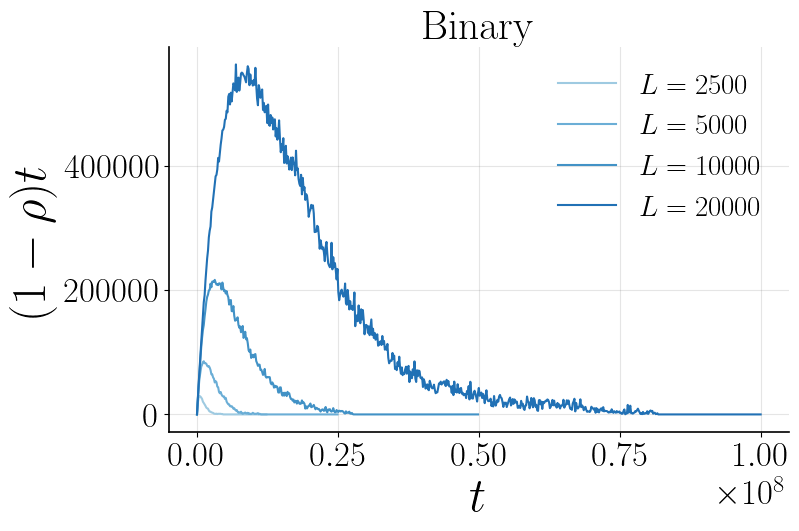

In [9]:
epsilon_c = 0.212925

C = 12
tf = 0.15 * 10**8
plt.figure(figsize=(8,5))
for j, L in enumerate(L_vals):
    c = cmap2(j+3)
    time_vals = np.array([i * time_step for i in range(0, round(L*time_prefact / time_step))])
    orig_data = 1-collected_rhos[L][epsilon_c]
    plt.plot(
        (time_vals)[0::], 
        (orig_data * time_vals)[0::], 
        label = fr"$L = {L}$",
        # fmt='--',  
        # markersize=3,
        # marker = "o",
        # capsize=3,
        c=c
        )
    # plt.axvline(C * L ** 1.4, c=c)


plt.xlabel(r"$t$")
plt.ylabel(r"$(1 - \rho)t$")
plt.legend()
plt.title(fr"Binary")
# plt.xlim(np.log10(0.001), np.log10(1))
# plt.ylim(0.7, 0.77)
# plt.xlim(0, 0.8 * 10**8)

plt.show()

/var/folders/0k/n4x5z88x1rx124p1g1l55hmc0000gn/T/ipykernel_44727/3222527682.py:8: RuntimeWarning: divide by zero encountered in log10
  np.log10(time_vals)[1::],


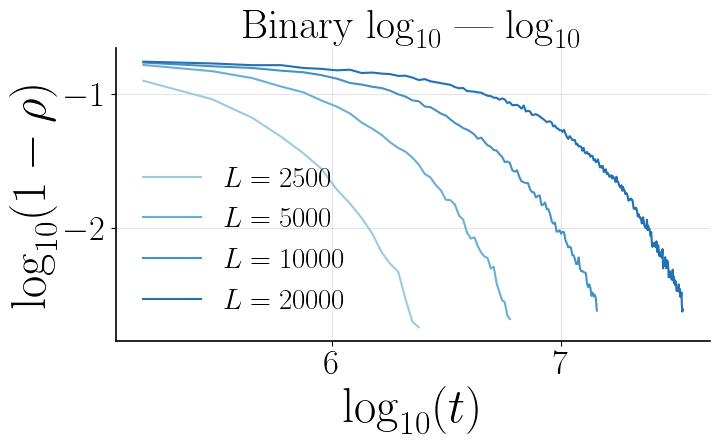

In [10]:

plt.figure(figsize=(8,5))
for j, L in enumerate(L_vals):
    c = cmap2(j+3)
    time_vals = np.array([i * time_step for i in range(0, round(L*time_prefact / time_step))])
    time_vals = [t for t in time_vals if t <= 12.0* C * L ** 1.25]
    orig_data = (1-collected_rhos[L][epsilon_c])[0:len(time_vals)]
    plt.plot(
        np.log10(time_vals)[1::], 
        np.log10((orig_data))[1::], 
        label = fr"$L = {L}$",
        # fmt='--',  
        # markersize=3,
        # marker = "o",
        # capsize=3,
        c=c
        )

# plt.axvline(0.29450750, c = 'k', label=f"x = 0.29450750 (old trans)")
plt.title(fr"Binary $\log_{{10}}$ | $\log_{{10}}$")
plt.xlabel(r"$\log_{10}(t)$")
plt.ylabel(r"$\log_{10}(1 - \rho)$")
plt.legend()
# plt.xlim(np.log10(0.001), np.log10(1))
# plt.ylim(0.7, 0.77)
plt.tight_layout()
# plt.savefig(f"figs/time_random/n_a{a_val_name}/z_estimate.png")

plt.show()

/var/folders/0k/n4x5z88x1rx124p1g1l55hmc0000gn/T/ipykernel_44727/783337345.py:12: RuntimeWarning: divide by zero encountered in log10
  np.log10((time_vals/(L ** z_guess)))[0::],
/var/folders/0k/n4x5z88x1rx124p1g1l55hmc0000gn/T/ipykernel_44727/783337345.py:13: RuntimeWarning: divide by zero encountered in log10
  np.log10((orig_data * time_vals ** found_delta))[0::],


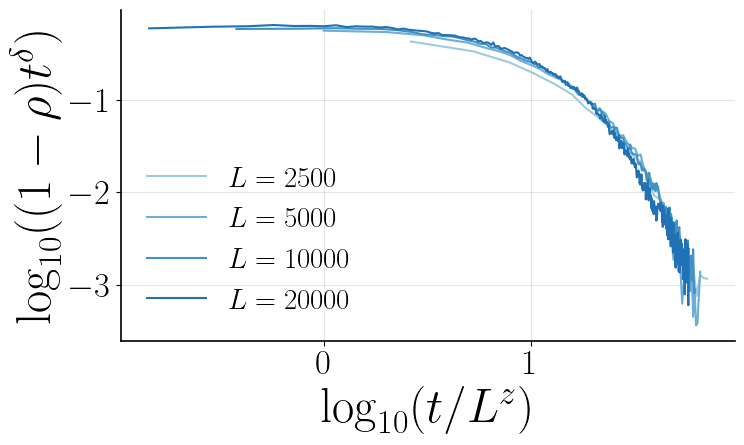

In [12]:
epsilon_c = 0.212925
z_guess = 1.4
found_delta = 0.1035

plt.figure(figsize=(8,5))
for j, L in enumerate(L_vals):
    c = cmap2(j+3)
    time_vals = [i * time_step for i in range(0, round(L*time_prefact / time_step))]
    time_vals = np.array([t for t in time_vals if t <= 13.0* C * L ** 1.3])
    orig_data = np.array((1-collected_rhos[L][epsilon_c])[0:len(time_vals)])
    plt.plot(
        np.log10((time_vals/(L ** z_guess)))[0::], 
        np.log10((orig_data * time_vals ** found_delta))[0::], 
        label = fr"$L = {L}$",
        # fmt='--',  
        # markersize=3,
        # marker = "o",
        # capsize=3,
        c=c
        )

# plt.axvline(0.29450750, c = 'k', label=f"x = 0.29450750 (old trans)")
# plt.title(fr"$\log_{{10}}$ | $\log_{{10}}$ Binary: Collapse $\|$ $\epsilon = {epsilon_c}$ $\|$ $\delta = {found_delta}$ $\|$ $z = {z_guess}$")
plt.xlabel(r"$\log_{10}(t/L^z)$")
plt.ylabel(r"$\log_{10}((1 - \rho)t^\delta)$")
plt.legend()
# plt.xlim(np.log10(0.001), np.log10(1))
# plt.ylim(0.7, 0.77)
plt.tight_layout()
plt.savefig(f"figs/time_random/binary/binstav_determining_z.png")
plt.show()

In [9]:
epsilon_c = 0.25375
z_guess = 1.6
found_delta = 0.115

plt.figure(figsize=(8,5))
for j, L in enumerate(L_vals):
    c = cmap2(j+3)
    time_vals = np.array([i * time_step for i in range(0, round(L*time_prefact / time_step))])
    time_vals = np.array([t for t in time_vals if t <= 2*C * L ** 1.6])
    orig_data = np.array((1-collected_rhos[L][epsilon_c])[0:len(time_vals)])
    plt.plot(
        np.log10((time_vals/(L ** z_guess)))[0::], 
        np.log10((orig_data * time_vals**found_delta))[0::], 
        label = fr"$L = {L}$",
        # fmt='--',  
        # markersize=3,
        # marker = "o",
        # capsize=3,
        c=c
        )

# plt.axvline(0.29450750, c = 'k', label=f"x = 0.29450750 (old trans)")
plt.title(fr"$\log_{{10}}$ | $\log_{{10}}$ Broad: $a = {a_val}$ Collapse $\|$ $\epsilon = {epsilon_c}$ $\|$ $\delta = {found_delta}$ $\|$ $z = {z_guess}$")
plt.xlabel(r"$\log_{10}(t/L^z)$")
plt.ylabel(r"$\log_{10}((1 - \rho)t^\delta)$")
plt.legend()
# plt.xlim(np.log10(0.001), np.log10(1))
# plt.ylim(0.7, 0.77)
plt.tight_layout()
# plt.savefig(f"figs/time_random/sigma{sigma_val_name}/fss_z_estimate.png")
plt.show()

KeyError: 0.25375

<Figure size 800x500 with 0 Axes>